# Term Deposit Subscription Prediction

## Introduction

Term deposits are one of the most widely offered investment products in the banking sector. Banks conduct direct marketing campaigns to encourage customers to subscribe to these deposits, but only a limited number of customers respond positively. Predicting customer subscription behavior helps financial institutions improve marketing efficiency and optimize campaign costs.

This project uses the **Bank Marketing Dataset** from the **UCI Machine Learning Repository** to analyze customer demographic information, financial characteristics, and previous marketing campaign data. The dataset is explored, cleaned, and preprocessed to prepare it for machine learning.

Machine learning classification models are developed to predict whether a customer will subscribe to a term deposit. The models are evaluated using multiple performance metrics, and Explainable AI (SHAP) is used to interpret model predictions and identify the factors influencing customer decisions.

## Problem Statement

Banks invest significant resources in direct marketing campaigns to promote term deposit subscriptions. However, contacting every customer does not guarantee a positive response, making these campaigns both time-consuming and costly.

The challenge is to accurately identify customers who are more likely to subscribe to a term deposit based on their demographic information, financial characteristics, and previous marketing interactions. Developing a predictive model can help banks target the right customers, improve campaign efficiency, and support data-driven marketing decisions.

## Project Objectives

The main objectives of this project are:

- Understand the structure and characteristics of the Bank Marketing dataset.
- Perform data cleaning and preprocessing to prepare the dataset for analysis.
- Explore customer behavior using Exploratory Data Analysis (EDA).
- Encode categorical variables for machine learning models.
- Develop classification models to predict term deposit subscription.
- Evaluate model performance using appropriate classification metrics.
- Compare different machine learning models to identify the best-performing model.
- Interpret model predictions using Explainable AI (SHAP).
- Generate meaningful business insights and recommendations based on the analysis.

## Dataset Information

This project uses the **Bank Marketing Dataset** obtained from the **UCI Machine Learning Repository**.

**Dataset Source:**  
https://archive.ics.uci.edu/dataset/222/bank+marketing

The dataset contains customer demographic information, financial details, and marketing campaign records collected during direct marketing campaigns conducted by a Portuguese banking institution.

The primary objective of this dataset is to analyze customer characteristics and predict whether a customer will subscribe to a term deposit based on demographic, financial, and campaign-related features.

Each record represents an individual bank customer and includes information such as age, job, marital status, education, account balance, housing loan, personal loan, contact type, campaign duration, previous campaign outcomes, and other relevant customer attributes.

The target variable in this dataset is **y**, where **"yes"** indicates that the customer subscribed to a term deposit and **"no"** indicates that the customer did not subscribe.

### Target Variable

| Value | Meaning |
|--------|---------|
| no | Customer did not subscribe to the term deposit |
| yes | Customer subscribed to the term deposit |

### Dataset Summary

| Attribute | Description |
|------------|------------|
| Dataset Name | Bank Marketing Dataset |
| Source | UCI Machine Learning Repository |
| File Used | bank-full.csv |
| Problem Type | Binary Classification |
| Target Variable | y |
| Domain | Banking and Marketing |

## Dataset Understanding and Description

Understanding the dataset is an essential step before performing data cleaning, exploratory data analysis, and machine learning model development.

This project uses the **Bank Marketing Dataset**, which contains customer demographic information, financial details, and marketing campaign-related attributes collected during direct marketing campaigns conducted by a Portuguese banking institution.

The objective is to predict whether a customer is likely to subscribe to a term deposit based on demographic information, financial characteristics, and previous marketing campaign interactions.


### Dataset Features

| Feature | Description |
|----------|-------------|
| age | Customer age |
| job | Type of job |
| marital | Marital status |
| education | Education level |
| default | Credit in default status |
| balance | Average yearly account balance |
| housing | Housing loan status |
| loan | Personal loan status |
| contact | Communication contact type |
| day | Last contact day of the month |
| month | Last contact month |
| duration | Duration of the last contact (seconds) |
| campaign | Number of contacts during the current campaign |
| pdays | Number of days since the customer was last contacted |
| previous | Number of contacts before the current campaign |
| poutcome | Outcome of the previous marketing campaign |
| y | Target variable indicating term deposit subscription |


## Import Required Libraries

Before beginning the data analysis and machine learning process, the required Python libraries are imported.

These libraries provide essential functionalities for data loading, preprocessing, visualization, classification modeling, performance evaluation, and explainable artificial intelligence (XAI).

Pandas and NumPy are used for data manipulation and numerical computations.

Matplotlib and Seaborn are used to create visualizations for exploratory data analysis.

Scikit-learn is used for data preprocessing, model training, prediction, and performance evaluation. SHAP is used to interpret machine learning models by explaining how individual features contribute to model predictions.

In [1]:
# Data Manipulation

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Explainable AI

import shap

## Load Dataset

The Bank Marketing Dataset is loaded into a Pandas DataFrame for analysis.

A DataFrame is a tabular data structure consisting of rows and columns, similar to an Excel spreadsheet. It allows efficient data exploration, manipulation, and analysis.

A copy of the original dataset is also created to preserve the raw data while performing data cleaning and preprocessing operations.

In [58]:
# Load dataset into a Pandas DataFrame

df = pd.read_csv("../dataset/bank-full.csv", sep=";")

# Create a copy of the original dataset

df_clean = df.copy()

## Dataset Preview

After loading the dataset, the first five records are displayed to verify that the dataset has been loaded successfully and to gain an initial understanding of its structure.

In [59]:
# Display first five records

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [60]:
# Display the first five records of the copied dataset

df_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## Data Cleaning and Preparation

Data cleaning is an important step in the machine learning workflow.

The objective of this phase is to identify missing values, verify dataset quality, and prepare the data for analysis and model development.

### Dataset Shape

Understanding the size of the dataset is an important step before performing data cleaning and analysis.

The shape of the dataset provides information about the total number of records and features available for term deposit subscription prediction. This helps estimate the overall dataset size and understand the amount of information available for machine learning model development.

In [5]:
# Display the shape of the dataset

df.shape

(45211, 17)

#### Observation

The dataset contains **45,211 records** and **17 columns**.

The dataset is sufficiently large for machine learning tasks and contains a diverse set of customer demographic, financial, and marketing campaign attributes that can be used to predict term deposit subscription.

### Dataset Information

The dataset information is examined to understand the dataset structure, including the number of entries, column names, data types, and non-null values. This helps identify missing values before data preprocessing.

In [6]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


#### Observation

The dataset contains **45,211 records** and **17 features**. All features have **45,211 non-null values**, indicating that there are **no missing values** in the dataset. The dataset includes **7 numerical features** and **10 categorical features**, making it suitable for data preprocessing and machine learning model development.

### Duplicate Records

Duplicate records are checked to ensure data quality before performing exploratory data analysis and machine learning. Removing duplicate records helps prevent biased analysis and improves model reliability.

In [7]:
# Check duplicate records

print("Duplicate Records: ", df.duplicated().sum())

Duplicate Records:  0


#### Observation

No duplicate records were found in the dataset. Therefore, no duplicate rows need to be removed before proceeding with data analysis and machine learning.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify patterns, and discover meaningful insights from customer and marketing campaign data.

The insights obtained during EDA help understand customer behavior and support the development of effective machine learning models for term deposit subscription prediction.

### Descriptive Statistics

Descriptive statistics provide a statistical summary of the numerical features in the dataset, including measures such as count, mean, standard deviation, minimum, maximum, and quartiles.

This helps understand the overall distribution and characteristics of the numerical variables before visualization and model development.

In [8]:
# Display descriptive statistics of numerical features

df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


#### Observation

The numerical features exhibit considerable variation in their distributions. The average customer age is approximately **41 years**, while the average account balance is around **1,362**. Marketing campaign-related variables such as **duration**, **campaign**, and **previous** show a wide range of values, indicating variability in customer interactions. Some numerical features also contain extreme values, which will be examined further during outlier analysis.

### Term Deposit Subscription Distribution

The target variable (**y**) indicates whether a customer subscribed to a term deposit after the marketing campaign.

Analyzing its distribution helps understand the class balance in the dataset before developing machine learning models.

In [9]:
# Display the distribution of the target variable

df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

#### Term Deposit Subscription Distribution Visualization

A bar chart is used to visualize the distribution of customers who subscribed and did not subscribe to a term deposit.

This visualization provides a clear comparison between the two target classes and highlights the overall class distribution.

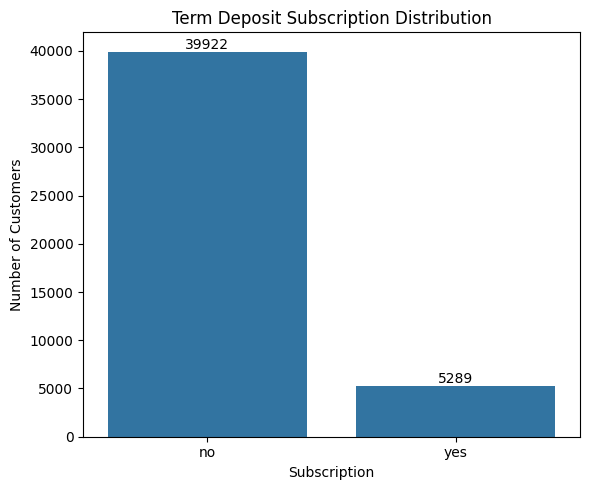

In [10]:
# Plot the distribution of the target variable

plt.figure(figsize=(6, 5))

ax = sns.countplot(
    data=df,
    x="y"
)

# Add data labels
ax.bar_label(ax.containers[0])

plt.title("Term Deposit Subscription Distribution")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/01_term_deposit_subscription_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The target variable distribution indicates that **39,922** customers did not subscribe to a term deposit, while only **5,289** customers subscribed. This shows that the dataset is **imbalanced**, with the majority of customers belonging to the **'no'** class. Therefore, model performance should be evaluated using metrics such as **F1-score**, **ROC-AUC**, and the **Confusion Matrix**, rather than relying solely on accuracy.

### Age Distribution

The **age** feature represents the age of each customer in the dataset.

Analyzing its distribution helps understand the age profile of customers and identify any unusual patterns or potential outliers before model development.

In [11]:
# Display summary statistics for age

df["age"].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

#### Age Distribution Visualization

A histogram is used to visualize the distribution of customer ages.

This visualization helps understand the frequency of different age groups and identify the overall distribution pattern.

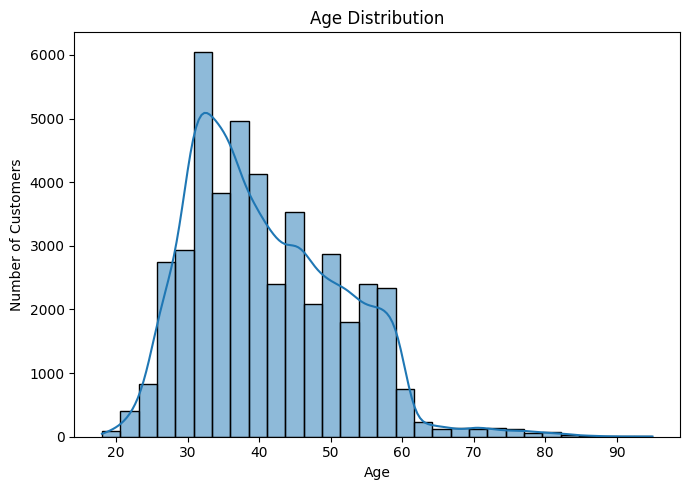

In [12]:
# Plot the age distribution

plt.figure(figsize=(7, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/02_age_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The age distribution shows that most customers are between **30 and 50 years** of age, with the highest concentration in the early **30s**. The distribution is **positively skewed (right-skewed)**, indicating that the number of customers gradually decreases as age increases. A relatively small number of customers are above **60 years** of age, suggesting that older customers represent a smaller portion of the dataset.

### Age Box Plot

A box plot is used to visualize the spread of customer ages and identify potential outliers.

It provides a summary of the age distribution based on the median, quartiles, and extreme values.

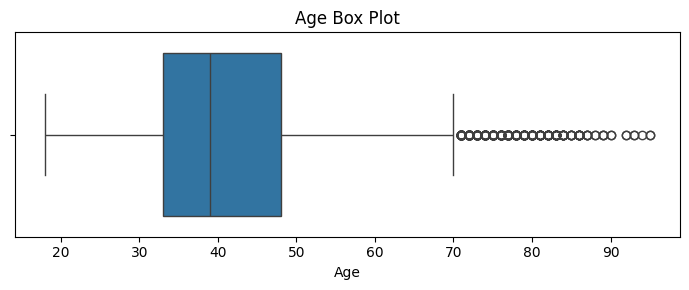

In [13]:
# Plot the age box plot

plt.figure(figsize=(7, 3))

sns.boxplot(
    data=df,
    x="age"
)

plt.title("Age Box Plot")
plt.xlabel("Age")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/03_age_boxplot.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The box plot indicates that the majority of customers are between approximately **33 and 49 years** of age, with a median age of around **39 years**. Several **upper outliers** are present beyond the age of **70**, indicating a small number of older customers in the dataset. No significant lower outliers are observed.

### Job Distribution

The **job** feature represents the occupation of each customer included in the marketing campaign.

Analyzing the distribution of customer occupations helps understand the composition of the dataset and identify the most common customer groups.

In [14]:
# Display the distribution of customer occupations

df["job"].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

#### Job Distribution Visualization

A bar chart is used to visualize the distribution of customer occupations.

This visualization provides a clear comparison of the number of customers in each job category.

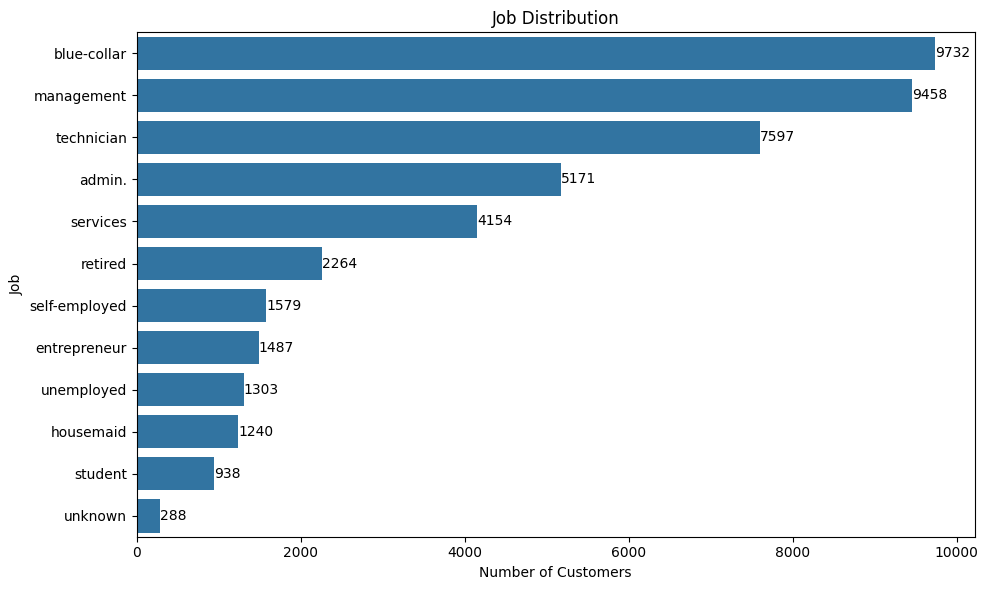

In [15]:
# Plot the distribution of customer occupations

# For Proper Order
job_counts = df["job"].value_counts()

plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=df,
    y="job",
    order=job_counts.index
)

# Add data labels
ax.bar_label(ax.containers[0])

plt.title("Job Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/04_job_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The job distribution indicates that **blue-collar (9,732)** and **management (9,458)** are the most common occupations in the dataset, followed by **technician (7,597)** and **admin. (5,171)**. Occupations such as **student (938)** and **unknown (288)** have the lowest representation. This suggests that the dataset is primarily composed of working professionals from blue-collar, management, and technical occupations.

### Term Deposit Subscription Rate by Job

Customer occupation can influence financial behavior and response to marketing campaigns.

This analysis examines the **subscription rate** across different job categories to identify which occupational groups are more likely to subscribe to a term deposit.

In [16]:
# Calculate subscription rate (%) for each job category

subscription_rate = (
    pd.crosstab(
        df["job"],
        df["y"],
        normalize="index"
    )["yes"] * 100
).sort_values(ascending=False)

subscription_rate.round(2)

job
student          28.68
retired          22.79
unemployed       15.50
management       13.76
admin.           12.20
self-employed    11.84
unknown          11.81
technician       11.06
services          8.88
housemaid         8.79
entrepreneur      8.27
blue-collar       7.27
Name: yes, dtype: float64

#### Term Deposit Subscription Rate by Job Visualization

A horizontal bar chart is used to compare the percentage of customers who subscribed to a term deposit across different job categories.

The job categories are arranged in descending order of subscription rate, making it easier to identify the occupations with the highest and lowest conversion rates.

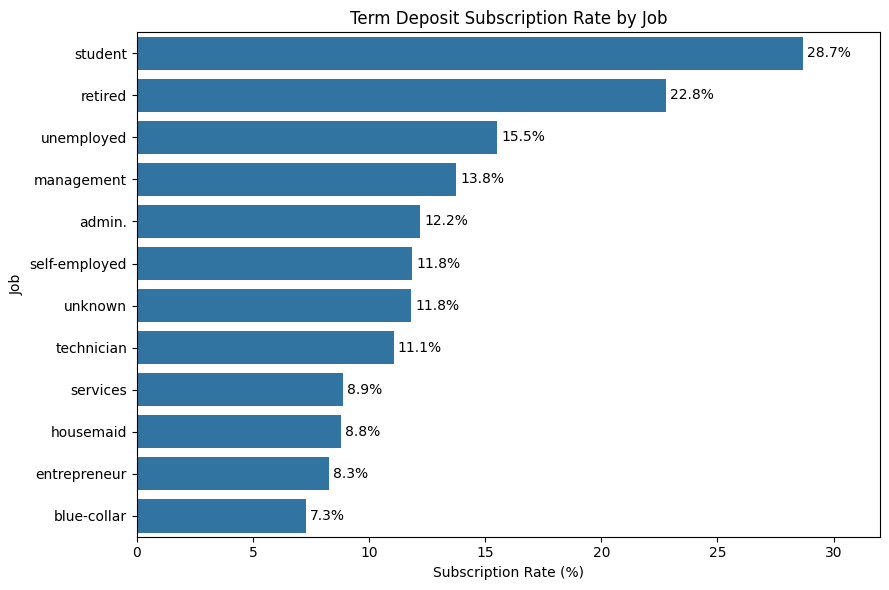

In [17]:
# Plot subscription rate by job category

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=subscription_rate.values,
    y=subscription_rate.index
)

# Add percentage labels
ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

# Add extra space for labels
plt.xlim(0, 32)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

# Save figure
plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/05_subscription_rate_by_job.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The subscription rate varies across different job categories. **Students (28.7%)** and **retired customers (22.8%)** have the highest term deposit subscription rates, indicating they are more responsive to the marketing campaign. In contrast, **entrepreneurs (8.3%)**, **housemaids (8.8%)**, and **services employees (8.9%)** show the lowest subscription rates. Overall, the results suggest that customer occupation has a noticeable influence on the likelihood of subscribing to a term deposit.

### Education Distribution

The **education** feature represents the educational qualification of each customer.

Analyzing the distribution of education levels helps understand the educational background of customers included in the marketing campaign.

In [18]:
# Display the distribution of education levels

df["education"].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

#### Education Distribution Visualization

A horizontal bar chart is used to compare the number of customers across different education levels.

The education categories are arranged in descending order of frequency for better comparison and readability.

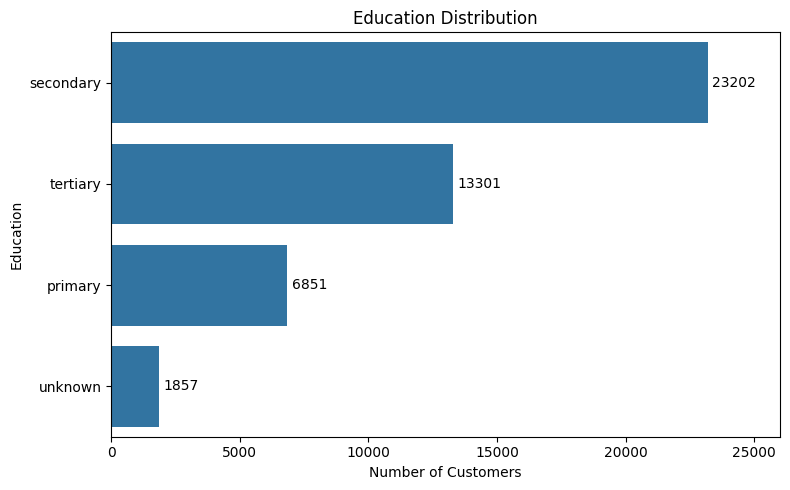

In [19]:
# Calculate education counts

education_counts = df["education"].value_counts()

# Plot education distribution

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    y="education",
    order=education_counts.index
)

# Add extra space for labels
plt.xlim(0, 26000)

# Add data labels
ax.bar_label(ax.containers[0],
    padding=3)


plt.title("Education Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Education")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/06_education_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The education distribution shows that the majority of customers have a **secondary education (23,202)**, followed by **tertiary education (13,301)**. Customers with **primary education (6,851)** represent a smaller proportion of the dataset, while only **1,857** customers have an **unknown** education level. Overall, the dataset is predominantly composed of customers with secondary and tertiary educational backgrounds.

### Term Deposit Subscription Rate by Education

Education level can influence customers' financial awareness and decision-making.

This analysis examines the subscription rate across different education levels to identify which groups are more likely to subscribe to a term deposit.

In [20]:
# Calculate subscription rate (%) for each education level

education_subscription_rate = (
    pd.crosstab(
        df["education"],
        df["y"],
        normalize="index"
    )["yes"] * 100
).sort_values(ascending=False)

education_subscription_rate.round(2)

education
tertiary     15.01
unknown      13.57
secondary    10.56
primary       8.63
Name: yes, dtype: float64

#### Term Deposit Subscription Rate by Education Visualization

A horizontal bar chart is used to compare the percentage of customers who subscribed to a term deposit across different education levels.

The education levels are arranged in descending order of subscription rate, making it easier to identify the groups with the highest and lowest conversion rates.

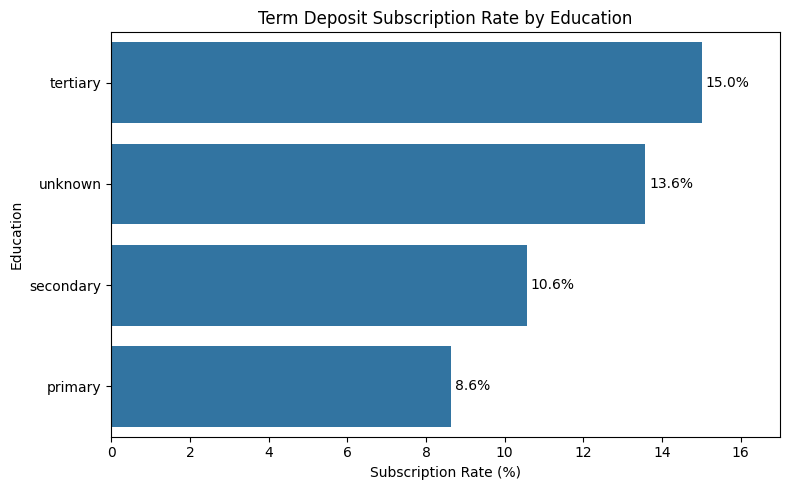

In [21]:
# Plot subscription rate by education level

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=education_subscription_rate.values,
    y=education_subscription_rate.index
)

# Add percentage labels
ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

# Add extra space for labels
plt.xlim(0, 17)

plt.title("Term Deposit Subscription Rate by Education")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Education")

plt.tight_layout()

# plt.savefig(
#     "../outputs/figures/07_subscription_rate_by_education.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The subscription rate differs across education levels. Customers with **tertiary education (15.0%)** have the highest subscription rate, followed by those with **unknown education (13.6%)** and **secondary education (10.6%)**. Customers with **primary education (8.6%)** have the lowest subscription rate. Overall, the results suggest that customers with higher educational qualifications tend to have a greater likelihood of subscribing to a term deposit.

### Balance Distribution

The **balance** feature represents the average yearly account balance of each customer.

Analyzing the distribution of account balances helps understand customers' financial profiles and identify potential outliers before model development.

In [22]:
# Display summary statistics for account balance

df["balance"].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

#### Balance Box Plot

A box plot is used to examine the distribution of customer account balances and identify potential outliers.

This visualization summarizes the data using quartiles and highlights unusually high or low account balance values.

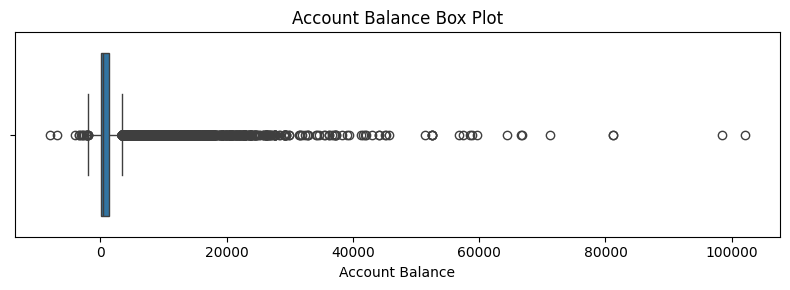

In [23]:
# Plot the account balance box plot

plt.figure(figsize=(8, 3))

sns.boxplot(
    data=df,
    x="balance"
)

plt.title("Account Balance Box Plot")
plt.xlabel("Account Balance")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/08_balance_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The account balance distribution is highly **right-skewed**, with most customers having relatively low account balances. The box plot reveals a large number of **high-value outliers**, indicating that a small proportion of customers maintain significantly higher balances than the majority. This suggests substantial variability in customer account balances across the dataset.

### Previous Campaign Outcome Distribution

The **poutcome** feature represents the outcome of the customer's previous marketing campaign interaction.

Analyzing this feature helps understand the effectiveness of previous campaigns and the distribution of different campaign outcomes among customers.

In [24]:
# Display the distribution of previous campaign outcomes

df["poutcome"].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

#### Previous Campaign Outcome Distribution Visualization

A horizontal bar chart is used to compare the frequency of different previous campaign outcomes.

The categories are arranged in descending order to provide a clear comparison of campaign results.

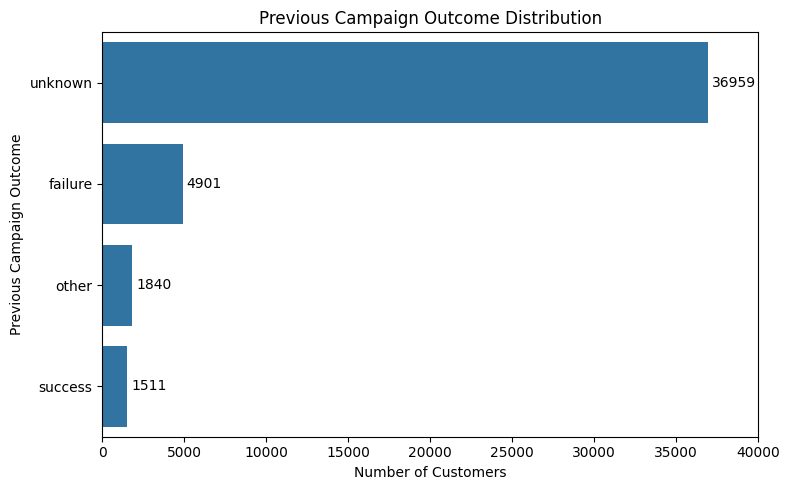

In [28]:
# Calculate previous campaign outcome counts

poutcome_counts = df["poutcome"].value_counts()

# Plot previous campaign outcome distribution

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    y="poutcome",
    order=poutcome_counts.index
)

# Add extra space for labels
plt.xlim(0, 40000)

# Add data labels
ax.bar_label(ax.containers[0], fmt="%d", padding=3)

plt.title("Previous Campaign Outcome Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Previous Campaign Outcome")

plt.tight_layout()



# plt.savefig(
#     "../outputs/figures/09_previous_campaign_outcome_distribution.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### Observation

The previous campaign outcome distribution shows that the majority of customers (**36,959**) have an **unknown** previous campaign outcome, indicating that most customers either had no recorded outcome or were not previously contacted. Among the known outcomes, **failure (4,901)** is the most common, followed by **other (1,840)** and **success (1,511)**. This suggests that only a relatively small proportion of customers have documented outcomes from previous marketing campaigns.

### Term Deposit Subscription Rate by Previous Campaign Outcome

The outcome of a customer's previous marketing campaign can significantly influence their response to future campaigns.

This analysis compares the subscription rate across different previous campaign outcomes to identify which customer groups are more likely to subscribe to a term deposit.

In [29]:
# Calculate subscription rate (%) by previous campaign outcome

poutcome_subscription_rate = (
    pd.crosstab(
        df["poutcome"],
        df["y"],
        normalize="index"
    )["yes"] * 100
).sort_values(ascending=False)

poutcome_subscription_rate.round(2)

poutcome
success    64.73
other      16.68
failure    12.61
unknown     9.16
Name: yes, dtype: float64

#### Term Deposit Subscription Rate by Previous Campaign Outcome Visualization

A horizontal bar chart is used to compare the percentage of customers who subscribed to a term deposit across different previous campaign outcomes.

The outcomes are arranged in descending order of subscription rate to highlight the most effective previous campaign results.

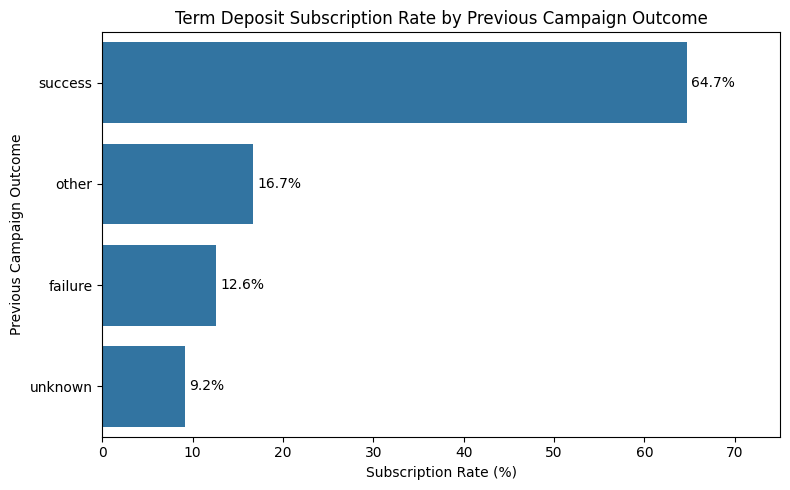

In [33]:
# Plot subscription rate by previous campaign outcome

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=poutcome_subscription_rate.values,
    y=poutcome_subscription_rate.index
)

# Add percentage labels
ax.bar_label(
    ax.containers[0],
    fmt="%.1f%%",
    padding=3
)

# Add extra space for labels
plt.xlim(0, 75)

plt.title("Term Deposit Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Previous Campaign Outcome")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/10_subscription_rate_by_previous_campaign_outcome.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Observation

The subscription rate varies significantly based on the outcome of the previous marketing campaign. Customers with a **previous successful campaign outcome (64.7%)** have the highest likelihood of subscribing to a term deposit, which is substantially higher than all other groups. In comparison, customers with **other (16.7%)**, **failure (12.6%)**, and **unknown (9.2%)** outcomes show considerably lower subscription rates. These results indicate that the outcome of previous marketing campaigns is a strong predictor of future customer subscription behavior.

## Data Preprocessing

Data preprocessing is an essential step in the machine learning workflow.

The objective of this phase is to transform the raw dataset into a format suitable for model training by encoding categorical variables, selecting relevant features, splitting the dataset, and applying feature scaling where required.

### Encode Target Variable

The target variable (**y**) contains categorical values (**yes** and **no**).

Machine learning algorithms require numerical values, so the target variable is converted into binary format, where **yes = 1** and **no = 0**.

In [61]:
# Encode the target variable

df_clean["y"] = df_clean["y"].map({
    "no": 0,
    "yes": 1
})

# Verify the encoding
df_clean["y"].value_counts()

y
0    39922
1     5289
Name: count, dtype: int64

#### Observation

The target variable was successfully converted from categorical values (**yes** and **no**) into binary numerical values (**1** and **0**). This transformation makes the target variable compatible with machine learning algorithms while preserving the original class distribution.

### Display Unique Values of Categorical Features

The dataset contains several categorical features such as **job, marital, education, default, housing, loan, contact, month,** and **poutcome**.

These features are converted into numerical format using **One-Hot Encoding**, allowing machine learning algorithms to process categorical information without introducing ordinal relationships between categories.

In [62]:
# Display unique values of categorical features

for column in [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]:
    print(f"{column}: {df_clean[column].unique().tolist()}")

job: ['management', 'technician', 'entrepreneur', 'blue-collar', 'unknown', 'retired', 'admin.', 'services', 'self-employed', 'unemployed', 'housemaid', 'student']
marital: ['married', 'single', 'divorced']
education: ['tertiary', 'secondary', 'unknown', 'primary']
default: ['no', 'yes']
housing: ['yes', 'no']
loan: ['no', 'yes']
contact: ['unknown', 'cellular', 'telephone']
month: ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr', 'sep']
poutcome: ['unknown', 'failure', 'other', 'success']


#### Observation

The categorical features were inspected before encoding to verify the categories present in each variable. The dataset contains both **binary categorical features** (default, housing, and loan) and **multi-category features** (job, marital, education, contact, month, and poutcome). Based on this inspection, appropriate encoding techniques can be applied to each feature.

### Encode Binary Categorical Features

The binary categorical features contain only two categories (**yes** and **no**).

These features are encoded using binary mapping, where **yes = 1** and **no = 0**, making them suitable for machine learning algorithms while preserving their binary nature.

In [63]:
# Encode binary categorical features

binary_columns = ["default", "housing", "loan"]

for column in binary_columns:
    df_clean[column] = df_clean[column].map({
        "no": 0,
        "yes": 1
    })

# Display the first five rows
df_clean.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0,unknown,0
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0,unknown,0
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0,unknown,0
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0,unknown,0
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0,unknown,0


#### Observation

The binary categorical features were successfully encoded using binary mapping, where **yes** was represented as **1** and **no** as **0**. This preserves the original meaning of the features while converting them into a numerical format suitable for machine learning algorithms.

### Encode Multi-Category Features

The remaining categorical features contain multiple categories and cannot be represented using binary mapping.

These features are encoded using **One-Hot Encoding**, which creates separate binary columns for each category while avoiding ordinal relationships between categories by dropping the first category.

In [65]:
# Apply One-Hot Encoding to multi-category features

df_clean = pd.get_dummies(
    df_clean,
    columns=[
        "job",
        "marital",
        "education",
        "contact",
        "month",
        "poutcome"
    ],
    drop_first=True,
    dtype=int
)

# Display the first five rows
df_clean.head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,261,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
1,44,0,29,1,0,5,151,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
2,33,0,2,1,1,5,76,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
3,47,0,1506,1,0,5,92,1,-1,0,...,0,0,0,1,0,0,0,0,0,1
4,33,0,1,0,0,5,198,1,-1,0,...,0,0,0,1,0,0,0,0,0,1


#### Observation

The remaining categorical features were successfully encoded using **One-Hot Encoding**. Each category was converted into a separate binary feature, while the first category of each feature was dropped to avoid the dummy variable trap. As a result, the dataset has been transformed into a fully numerical format suitable for machine learning model development.

### Dataset Shape After Encoding

After encoding the categorical features, the dataset shape is examined to verify that the number of rows remains unchanged while the number of columns increases due to the creation of new binary features.

In [66]:
# Display dataset shape after encoding

df_clean.shape

(45211, 43)

#### Observation

After encoding, the dataset contains **45,211 rows** and **43 columns**. The number of rows remains unchanged, while the number of columns has increased from **17 to 43** due to the creation of binary features through One-Hot Encoding.

### Encoded Dataset Information

After applying binary mapping and One-Hot Encoding, the dataset information is examined to verify that all features have been successfully converted into numerical data types suitable for machine learning.

In [67]:
# Display dataset information after encoding

df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45211 non-null  int64
 1   default              45211 non-null  int64
 2   balance              45211 non-null  int64
 3   housing              45211 non-null  int64
 4   loan                 45211 non-null  int64
 5   day                  45211 non-null  int64
 6   duration             45211 non-null  int64
 7   campaign             45211 non-null  int64
 8   pdays                45211 non-null  int64
 9   previous             45211 non-null  int64
 10  y                    45211 non-null  int64
 11  job_blue-collar      45211 non-null  int64
 12  job_entrepreneur     45211 non-null  int64
 13  job_housemaid        45211 non-null  int64
 14  job_management       45211 non-null  int64
 15  job_retired          45211 non-null  int64
 16  job_self-employed    45211 non-nu

#### Observation

The dataset has been successfully transformed into a fully numerical format. All categorical features have been encoded, and no object or string data types remain. The dataset is now ready for feature selection and machine learning model training.

### Feature Correlation with Target Variable

The correlation between each feature and the target variable (**y**) is examined to identify the most influential predictors for term deposit subscription.

This analysis helps understand which features have the strongest positive or negative relationship with the target variable and provides insights for model interpretation.

In [85]:
# Calculate correlation with the target variable

target_correlation = (
    df_clean.corr()["y"]
    .drop("y")
    .sort_values(ascending=False)
    .round(3)
)

target_correlation

duration               0.395
poutcome_success       0.307
month_mar              0.129
month_oct              0.129
month_sep              0.123
pdays                  0.104
previous               0.093
job_retired            0.079
job_student            0.077
month_dec              0.075
education_tertiary     0.066
marital_single         0.064
balance                0.053
month_feb              0.038
job_management         0.033
poutcome_other         0.032
age                    0.025
job_unemployed         0.020
contact_telephone      0.014
education_unknown      0.012
job_self-employed      0.001
job_unknown            0.000
month_aug             -0.009
month_jan             -0.009
job_technician        -0.009
month_nov             -0.015
job_housemaid         -0.015
month_jun             -0.017
job_entrepreneur      -0.020
default               -0.022
job_services          -0.028
day                   -0.028
month_jul             -0.034
education_secondary   -0.036
marital_marrie

#### Observation

The correlation analysis indicates that **duration** has the strongest positive correlation with the target variable, followed by **poutcome_success** and a few other features with relatively weaker positive relationships. Most remaining features exhibit low positive or negative correlations, suggesting that the prediction of term deposit subscription depends on the combined effect of multiple features rather than a single predictor.

### Feature Selection

Feature selection is the process of separating the input features (**X**) from the target variable (**y**).

The target variable (**y**) represents whether a customer subscribed to a term deposit, while all remaining columns are used as input features for training the machine learning model.

In [77]:
# Separate features and target variable

X = df_clean.drop("y", axis=1)
y = df_clean["y"]

# Display the shape of features and target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (45211, 42)
Target Shape: (45211,)


#### Observation

The dataset was successfully divided into input features (**X**) and the target variable (**y**). The feature set contains **42 predictor variables**, while the target variable contains **45,211 observations**, making the dataset ready for train-test splitting.

### Train-Test Split

The dataset is divided into training and testing sets to evaluate the performance of the machine learning model on unseen data.

A **20% test size** is used, while **80%** of the data is reserved for training. The **stratify** parameter ensures that the class distribution remains consistent in both the training and testing datasets.

In [78]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display dataset shapes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (36168, 42)
X_test : (9043, 42)
y_train: (36168,)
y_test : (9043,)


#### Observation

The dataset was successfully divided into training and testing sets using an **80:20 ratio**. Stratified sampling was applied to preserve the original class distribution in both datasets, ensuring a fair and reliable evaluation of the machine learning models.

### Feature Scaling

Feature scaling is applied to standardize the numerical features so that they have a similar scale.

Standardization improves the performance of distance-based and gradient-based machine learning algorithms by ensuring that features with larger values do not dominate the learning process.

The scaler is fitted only on the training data and then applied to both the training and testing datasets to prevent data leakage.

In [79]:
# Initialize the scaler

scaler = StandardScaler()

# Scale the training and testing feature sets

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display dataset shapes

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

X_train_scaled: (36168, 42)
X_test_scaled : (9043, 42)


#### Observation

The feature values were successfully standardized using **StandardScaler**. The scaler was fitted on the training dataset and then applied to both the training and testing datasets, ensuring a consistent transformation while preventing data leakage.